In [27]:
# import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [28]:
iris = pd.read_csv('iris.csv')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


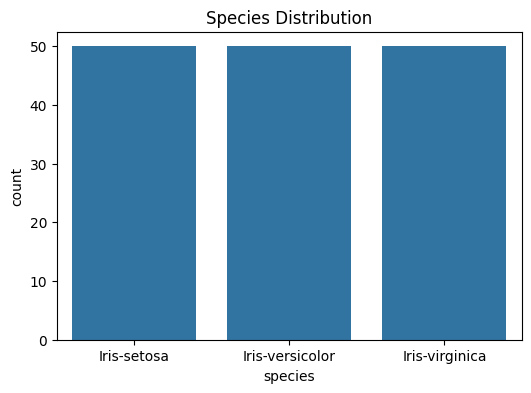

In [29]:
# countplot
plt.figure(figsize=(6,4))
sns.countplot(data=iris, x='species')
plt.title('Species Distribution')
plt.savefig('countplot.png')
plt.show()
plt.close()

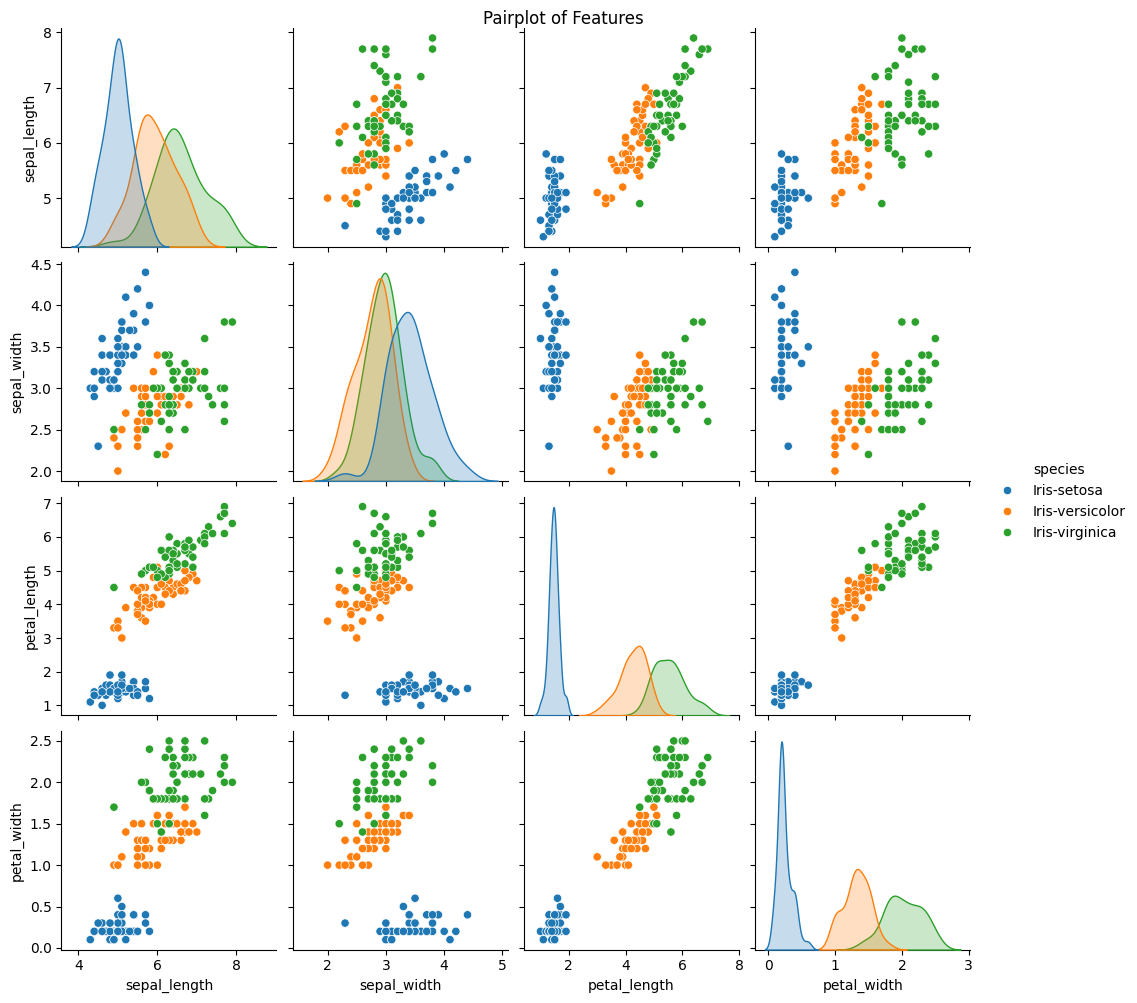

In [30]:
# pair plot
sns.pairplot(iris,hue='species')
plt.suptitle('Pairplot of Features', y=1)
plt.savefig('Pairplot.png')
plt.show()
plt.close()

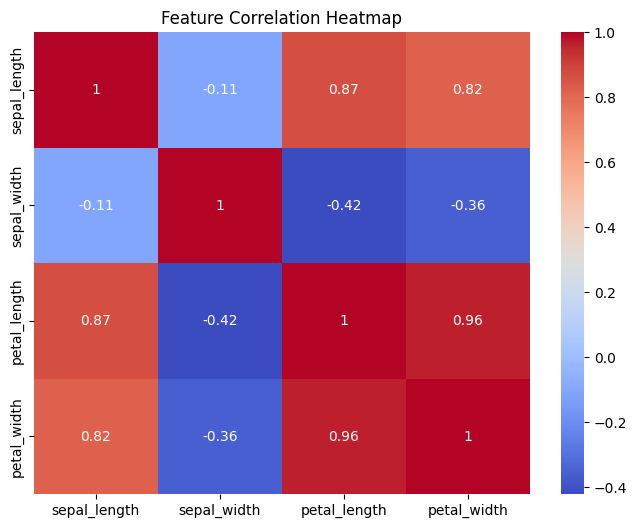

In [31]:
# correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(iris.drop('species',axis=1).corr(),annot=True,cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap')
plt.show()
plt.close()

In [32]:
x = iris.drop('species', axis=1)
y = iris['species']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [33]:
models = {
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(x_train_scaled,y_train)
    y_pred = model.predict(x_test_scaled)
    acc = accuracy_score(y_test,y_pred)
    results[name] = acc
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.2f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test,y_pred))
    print("Classification Report:")
    print(classification_report(y_test,y_pred))
    print("-"*30)

    

=== Random Forest ===
Accuracy: 1.00
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

------------------------------
=== Logistic Regression ===
Accuracy: 1.00
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.

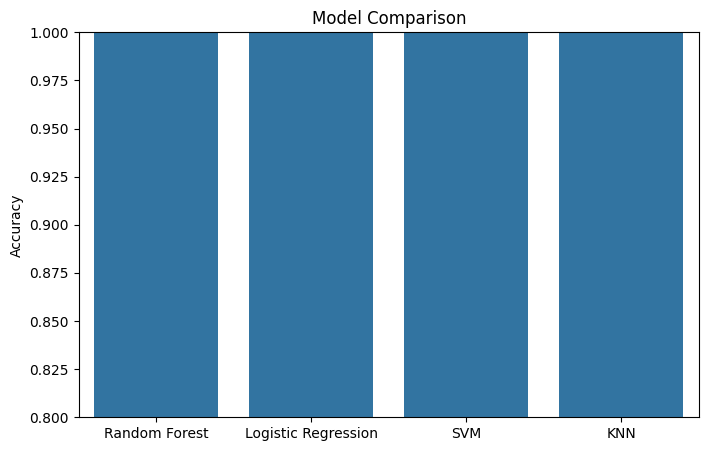

In [34]:
# bar plot for model accuracy
plt.figure(figsize = (8,5))
sns.barplot(x = list(results.keys()),y = list(results.values()))
plt.ylim(0.8,1)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.savefig('model_accuracy.png')
plt.show()
plt.close()